# 02 - Rank Momentum

This notebook computes Clenow-style momentum rankings from the cached S&P 500 OHLCV data. The default score is annualized exponential regression slope multiplied by R-squared.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from clenow.data import load_prices
from clenow.ranking import RankingConfig, rank_momentum

In [2]:
PRICES_PATH = PROJECT_ROOT / "data" / "processed" / "sp500_prices.parquet"
RANKINGS_PATH = PROJECT_ROOT / "data" / "processed" / "momentum_rankings.parquet"
RANKINGS_CSV_PATH = PROJECT_ROOT / "data" / "processed" / "momentum_rankings.csv"

config = RankingConfig(
    lookback_days=90,
    atr_window=20,
    trend_ma_window=100,
    trading_days=252,
    require_positive_slope=True,
    require_above_trend_ma=True,
    min_price=5.0,
    min_avg_dollar_volume=10_000_000.0,
)
config

RankingConfig(lookback_days=90, atr_window=20, trend_ma_window=100, gap_window=90, gap_threshold=None, trading_days=252, require_positive_slope=True, require_above_trend_ma=True, min_price=5.0, min_avg_dollar_volume=10000000.0)

In [3]:
prices = load_prices(PRICES_PATH)
print(f"Loaded {len(prices):,} rows across {prices['ticker'].nunique()} tickers")
print(f"Date range: {prices['date'].min().date()} to {prices['date'].max().date()}")
prices.head()

Loaded 377,954 rows across 504 tickers
Date range: 2023-05-23 to 2026-05-22


,date,ticker,Open,High,Low,Close,Adj Close,Volume
0,2023-05-23,A,129.029999,130.539993,127.910004,128.639999,125.737244,2784400.0
1,2023-05-24,A,115.199997,121.089996,113.279999,120.989998,118.259842,6850400.0
2,2023-05-25,A,121.410004,121.410004,117.639999,119.489998,116.793709,3218900.0
3,2023-05-26,A,120.070000,120.720001,118.379997,120.419998,117.702721,2089100.0
4,2023-05-30,A,120.010002,121.309998,117.669998,117.730003,115.073433,2094800.0


In [4]:
rankings = rank_momentum(prices, config=config)
RANKINGS_PATH.parent.mkdir(parents=True, exist_ok=True)
rankings.to_parquet(RANKINGS_PATH, index=False)
rankings.to_csv(RANKINGS_CSV_PATH, index=False)

print(f"Ranked {len(rankings)} eligible stocks")
rankings.head(25)

Ranked 205 eligible stocks


,rank,ticker,date,last_price,ATR20,MA100,avg_dollar_volume_20,candle_gap,max_gap_90,annualized_slope,r_squared,momentum_score,above_trend_ma,history_days
0,1,SNDK,2026-05-22,1478.689941,116.352704,763.578999,2.034255e+10,0.028420,0.130117,24.187924,0.861570,20.839589,True,320
1,2,CIEN,2026-05-22,583.739990,35.836505,382.623100,1.083841e+09,0.026142,0.126027,14.889722,0.956468,14.241541,True,753
2,3,LITE,2026-05-22,946.900024,84.689005,674.612800,5.872106e+09,0.019273,0.143062,15.909667,0.835655,13.294998,True,753
3,4,DELL,2026-05-22,295.190002,15.020998,162.690373,1.523937e+09,0.091771,0.103164,11.864750,0.950771,11.280654,True,753
4,5,INTC,2026-05-22,119.839996,8.884001,61.140400,1.669334e+10,0.004172,0.104947,15.171299,0.656575,9.961096,True,753
5,6,STX,2026-05-22,812.729980,49.380496,475.389870,3.529277e+09,0.002449,0.107782,9.336687,0.751424,7.015808,True,753
6,7,WDC,2026-05-22,484.279999,30.912003,314.856968,3.662958e+09,0.008569,0.122224,7.118080,0.831811,5.920896,True,753
7,8,VRT,2026-05-22,327.459991,18.900700,256.429684,1.930811e+09,0.019850,0.089969,6.095813,0.891507,5.434463,True,753
8,9,COHR,2026-05-22,377.570007,27.213503,265.652301,2.305883e+09,0.011733,0.143997,5.225678,0.863899,4.514457,True,753
9,10,GLW,2026-05-22,194.050003,13.788998,139.095191,2.875679e+09,0.001546,0.095216,5.252102,0.812214,4.265832,True,753


In [5]:
columns = [
    "rank",
    "ticker",
    "date",
    "last_price",
    "momentum_score",
    "annualized_slope",
    "r_squared",
    "ATR20",
    "MA100",
    "avg_dollar_volume_20",
]
rankings[columns].head(50)

,rank,ticker,date,last_price,momentum_score,annualized_slope,r_squared,ATR20,MA100,avg_dollar_volume_20
0,1,SNDK,2026-05-22,1478.689941,20.839589,24.187924,0.861570,116.352704,763.578999,2.034255e+10
1,2,CIEN,2026-05-22,583.739990,14.241541,14.889722,0.956468,35.836505,382.623100,1.083841e+09
2,3,LITE,2026-05-22,946.900024,13.294998,15.909667,0.835655,84.689005,674.612800,5.872106e+09
3,4,DELL,2026-05-22,295.190002,11.280654,11.864750,0.950771,15.020998,162.690373,1.523937e+09
4,5,INTC,2026-05-22,119.839996,9.961096,15.171299,0.656575,8.884001,61.140400,1.669334e+10
5,6,STX,2026-05-22,812.729980,7.015808,9.336687,0.751424,49.380496,475.389870,3.529277e+09
6,7,WDC,2026-05-22,484.279999,5.920896,7.118080,0.831811,30.912003,314.856968,3.662958e+09
7,8,VRT,2026-05-22,327.459991,5.434463,6.095813,0.891507,18.900700,256.429684,1.930811e+09
8,9,COHR,2026-05-22,377.570007,4.514457,5.225678,0.863899,27.213503,265.652301,2.305883e+09
9,10,GLW,2026-05-22,194.050003,4.265832,5.252102,0.812214,13.788998,139.095191,2.875679e+09


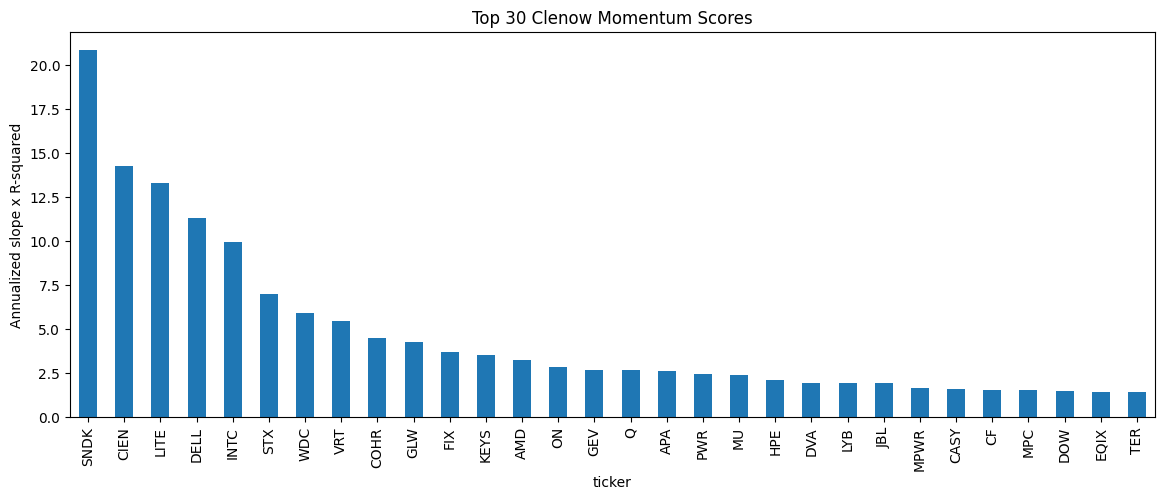

In [6]:
ax = rankings.head(30).plot.bar(
    x="ticker",
    y="momentum_score",
    figsize=(14, 5),
    title="Top 30 Clenow Momentum Scores",
    legend=False,
)
ax.set_ylabel("Annualized slope x R-squared");